In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
if_renormalon = False

In [3]:
result_set = {}
accuracies = ["fit_1","scan_1"]
for XLL in accuracies:
    result_set[XLL] = pd.read_csv("../result/"+XLL+".csv")

Import

In [4]:
import ast
def convert_to_list(string):
    corrected_string = string.replace("      ", ",")
    corrected_string = corrected_string.replace("     ", ",")
    corrected_string = corrected_string.replace("    ", ",") 
    corrected_string = corrected_string.replace("   ", ",") 
    corrected_string = corrected_string.replace("  ", ",")    
    corrected_string = corrected_string.replace(" ", ",")
    l=len(corrected_string)
    new_string=""
    for i in range(1,l-1):
        if (corrected_string[i]=="," and (corrected_string[i-1]=="[" or corrected_string[i+1]=="]")):
            new_string = new_string
        else:
            new_string = new_string + corrected_string[i]

    new_string = new_string + "]"
    new_string = "[" + new_string

    return ast.literal_eval(new_string)

αs_set_1 = {}
Ω1_set = {}
a_set_2 = {}

for XLL in accuracies:
    results_df = result_set[XLL]
    αs_set_1[XLL] = results_df['αs'].to_numpy()
    params = results_df['params'].apply(convert_to_list)
    params = np.array(params.to_list())

    rows = len(params)
    cols = len(params[0])
    a_list = {}

    if if_renormalon == False:
        for i in range(cols):
            a_list[i] = params[:,i]
    if if_renormalon == True:
        Ω1_array = params[:,0]
        Ω1_set[XLL] = Ω1_array
        for i in range(cols-1):
            a_list[i] = params[:,i+1]
            
    a_set_2[XLL] = pd.DataFrame(a_list)

    #print(a_list)

In [5]:
a_set_1 = {}
a_set = {}
αs_set = {}
for XLL in accuracies:
    a_list = {}
    a_set_1[XLL] = pd.DataFrame(a_set_2[XLL])
    df_αs = pd.DataFrame({"αs": αs_set_1[XLL]})
    df_total=pd.concat([df_αs,a_set_1[XLL]],axis=1)
    nonzero = df_total[(df_total != -1).all(axis=1)]
    print(len(nonzero))
    αs_set[XLL] = nonzero["αs"]
    for i in range(nonzero.shape[1]-1):
        a_list[i]= np.array(nonzero[i])
    a_set[XLL] = a_list

200
200


In [6]:
for XLL in accuracies:
    αs_array = αs_set[XLL]
    print(XLL)
    print(" as: med is",round(np.percentile(αs_array,50),4),", up is",round(np.percentile(αs_array,84)-np.percentile(αs_array,50),4),", down is",round(np.percentile(αs_array,50)-np.percentile(αs_array,16),4))
    print(" A: med is",round(np.percentile(a_set[XLL][0],50),3), ", up is",round(np.percentile(a_set[XLL][0],84)-np.percentile(a_set[XLL][0],50),3),", down is",round(np.percentile(a_set[XLL][0],50)-np.percentile(a_set[XLL][0],16),3) )
    print(" a1: med is",round(np.percentile(a_set[XLL][1],50),3),", up is",round(np.percentile(a_set[XLL][1],84)-np.percentile(a_set[XLL][1],50),3),", down is",round(np.percentile(a_set[XLL][1],50)-np.percentile(a_set[XLL][1],16),3) )
    print(" a2: med is",round(np.percentile(a_set[XLL][2],50),3),", up is",round(np.percentile(a_set[XLL][2],84)-np.percentile(a_set[XLL][2],50),3),", down is",round(np.percentile(a_set[XLL][2],50)-np.percentile(a_set[XLL][2],16),3) )
    print()

fit_1
 as: med is 0.118 , up is 0.0 , down is 0.0
 A: med is 0.865 , up is 0.004 , down is 0.003
 a1: med is 2.732 , up is 0.039 , down is 0.037
 a2: med is 1.136 , up is 0.011 , down is 0.011

scan_1
 as: med is 0.118 , up is 0.0 , down is 0.0
 A: med is 0.864 , up is 0.008 , down is 0.005
 a1: med is 2.74 , up is 0.11 , down is 0.144
 a2: med is 1.133 , up is 0.006 , down is 0.004



In [7]:
for XLL in accuracies:
    αs_array = αs_set[XLL]
    #print(XLL+" αs theoretical error is",round((max(αs_array)-min(αs_array))/2,5)) 
    print(XLL+" a1_up is",np.percentile(a_set[XLL][0],84.13),XLL+" a1_down is",np.percentile(a_set[XLL][0],15.87) )
    print(XLL+" a2_up is",np.percentile(a_set[XLL][1],84),XLL+" a2_down is",np.percentile(a_set[XLL][1],16) )

fit_1 a1_up is 0.868360935 fit_1 a1_down is 0.861495569
fit_1 a2_up is 2.7710643999999998 fit_1 a2_down is 2.69507
scan_1 a1_up is 0.871703496 scan_1 a1_down is 0.858735325
scan_1 a2_up is 2.850028 scan_1 a2_down is 2.5960144


Correlation

In [8]:
data = {}
mean = {}
df_set = {}
cov_matrix = {}
std_devs = {}
corr_matrix = {}

for XLL in accuracies:
    
    data[XLL]={}
    mean[XLL]={}

    a_list = a_set[XLL]

    l=len(a_list)
    for i in range(l):
        data[XLL][i] = a_list[i]
        mean[XLL][i] = np.mean(data[XLL][i])

    df_set[XLL]=pd.DataFrame(data[XLL])
    X = df_set[XLL].values

    cov_matrix[XLL] = np.cov(X, rowvar=False)
    std_devs[XLL] = np.sqrt(np.diag(cov_matrix[XLL]))
    corr_matrix[XLL] = cov_matrix[XLL] / np.outer(std_devs[XLL], std_devs[XLL])

for XLL in accuracies:
    display(XLL)
    display("mean:", mean[XLL])
    display("covariance matrix:", corr_matrix[XLL])
    display(df_set[XLL])

'fit_1'

'mean:'

{0: 0.86479815, 1: 2.7325557000000003, 2: 1.1359336}

'covariance matrix:'

array([[ 1.        , -0.60359339, -0.55788601],
       [-0.60359339,  1.        ,  0.80508719],
       [-0.55788601,  0.80508719,  1.        ]])

...

'mean:'

{0: 0.8650129, 1: 2.7259969, 2: 1.1339830499999999}

'covariance matrix:'

array([[ 1.        , -0.38291693,  0.8898324 ],
       [-0.38291693,  1.        , -0.56356817],
       [ 0.8898324 , -0.56356817,  1.        ]])

,0,1,2
0,0.86278,2.82123,1.13176
1,0.86204,2.80185,1.13218
2,0.85727,2.87801,1.12600
3,0.86357,2.67286,1.13513
4,0.86027,2.68901,1.13342
...,...,...,...
195,0.86686,2.58729,1.13592
196,0.86261,2.57985,1.13297
197,0.86313,2.84986,1.13050
198,0.86466,2.62974,1.13537


Plot

In [9]:
scale_68 = np.sqrt(2.279)
scale_95 = np.sqrt(5.991)

from matplotlib.patches import Ellipse
def draw_ellipse(mean, cov, scale, ax, **kwargs):

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    eigenvalues = 2.0 * scale * np.sqrt(eigenvalues)
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

    ell = Ellipse(xy=mean, width=eigenvalues[0], height=eigenvalues[1], angle=angle, **kwargs)
    
    ax.add_artist(ell)

In [10]:
data_set = {}

for XLL in accuracies:
    data_set[XLL] = df_set[XLL].copy()
    l = df_set[XLL].shape[0]
    XLL_series = pd.Series([XLL]*l)
    data_set[XLL]["XLL"] =  XLL_series

data_combined = pd.DataFrame()
df_c = pd.DataFrame()
for XLL in accuracies:
    data_combined = pd.concat([data_combined,data_set[XLL]],ignore_index=True)
    df_c = pd.concat([data_combined,df_set[XLL]],ignore_index=True)
#display(data_set['bbstar_fit_cut'][3])

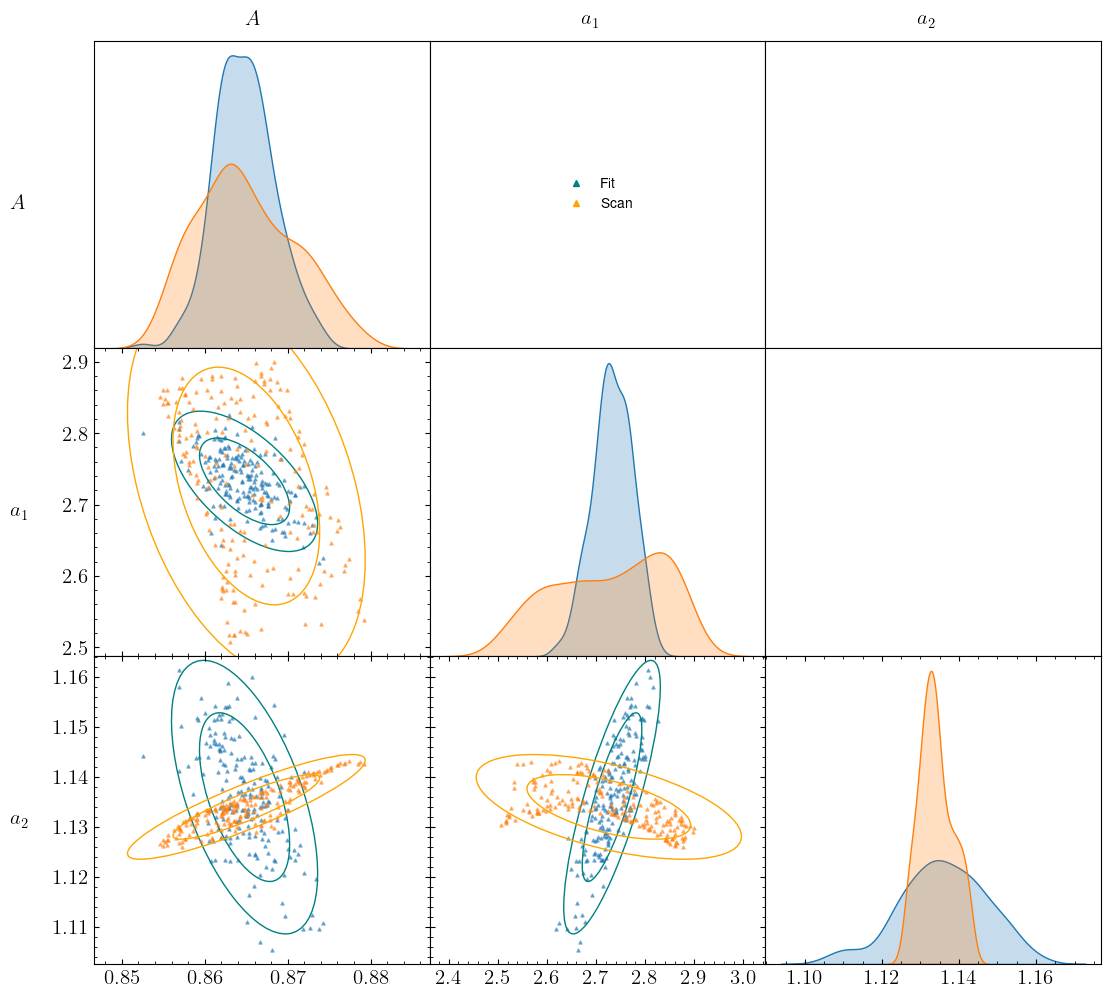

In [11]:
from scipy.stats import gaussian_kde
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(11, 10), sharex='col')
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axes.ravel()

sizeOfFont= 15
sizeOfTick = 15
sizeOfPoint = 5
transOfPoint = 0.5
shapeOfPoint = "^"

color = ["teal","orange"]
labels = [0,1,2]

data_set = {}

k=0
for XLL in accuracies:

    df = df_set[XLL].copy()

    for i in range(3):
        for j in range(0,i):  
            ax = axes[i, j]
            x=data[XLL][labels[j]]
            y=data[XLL][labels[i]]
            ax.scatter(x,y,s=sizeOfPoint, alpha=transOfPoint, marker=shapeOfPoint)
            mean = df.mean().values[[j, i]]
            cov = np.cov(df.values.T[[j, i]])
            draw_ellipse(mean, cov, scale_68, ax, edgecolor=color[k], fc='None')
            draw_ellipse(mean, cov, scale_95, ax, edgecolor=color[k], fc='None')

        ax = axes[i, i]
        x = data[XLL][labels[i]]
        sns.kdeplot(x, ax=ax, fill=True, bw_adjust=1, legend=False) 
        ax.set_ylabel('')

    k=k+1

#-------------------------------------------------------------------------------------------------------------------------

#-------------------------------------------------------------------------------------------------------------------------

#-------------------------------------------------------------------------------------------------------------------------
for i in range(3):
    for j in range(0,i):
        ax = axes[i,j]
        ax.minorticks_on()
        ax.tick_params(direction='in', top=True, right=True, labelsize = sizeOfFont)
        ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
        ax.set_xlabel('')
        ax.set_ylabel('')

for i in range(3):
    for j in range(i,3):
        axes[i,j].set_yticks([])

for i in range(3):
    for j in range(1,3):
        axes[i,j].set_yticklabels([])

axes[2,2].minorticks_on()
axes[2,2].tick_params(direction='in', top=True, right=True, labelsize = sizeOfFont)
axes[2,2].tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)  
#-------------------------------------------------------------------------------------------------------------------------

names=[r"\rm $A$",r"\rm $a_1$",r"\rm $a_2$"]
props = dict(boxstyle='round', facecolor='white', alpha=0)
i=0
for ax in axes[0, :]:
    ax.text(0.45, 1.1, names[i], transform=ax.transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
    i=i+1
j=0
for ax in axes[:, 0]:
    ax.text(-0.25, 0.5,  names[j], transform=ax.transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
    j=j+1

axes[0, 0].set_yticks([])


import matplotlib.lines as mlines
fit_cut_handle = mlines.Line2D([], [], color=color[0], marker=shapeOfPoint, linestyle='None', markersize=sizeOfPoint, label='Fit')
scan_handle = mlines.Line2D([], [], color=color[1], marker=shapeOfPoint, linestyle='None', markersize=sizeOfPoint, label='Scan')
axes[0, 1].legend(handles=[fit_cut_handle, scan_handle], loc='center', frameon=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)
plt.show()

fig.savefig('fit_1.pdf', bbox_inches='tight')